# OSRS NPC Image Generation
# Champion model -- LoRA fine-tune of Stable Diffusion 1.5 (full multi-class dataset)

Builds on Camille's `06_lora_feasibility.ipynb`: reuses its dedup + resize/pad preprocessing
output (`../data/chatheads_processed/`, 1,712 images) and the `metadata.jsonl` caption manifest
it already wrote (HuggingFace `imagefolder` format: `file_name` + `text`). That notebook's own
LoRA run only trained on the ~300-image "Human" subset as a feasibility MVP. This notebook is
the real **champion**: the same LoRA recipe, retrained on the **full** 1,712-image, 11-class
manifest, so it can actually generate NPCs across classes instead of just humans -- and so it's
a fair comparison against the from-scratch GAN challenger in `08_train_gan_challenger.ipynb`.

- **Base model:** `runwayml/stable-diffusion-v1-5`, fp16
- **Adapter:** LoRA, rank 8, applied via the stock HuggingFace `train_text_to_image_lora.py`
  (already vendored in this folder)
- **Data:** all 1,712 deduped, resized/padded 128x128 chatheads + their CLIP-derived captions
- **Conditioning:** free-text caption (e.g. `"Dwarf, Male, a beard, hat, found in Falador"`),
  matching the class label set used by the Problem-1 classifier so generations can later be fed
  through the champion `DualCNN` as an automatic "does this look like the intended class?" check.

In [1]:
import os
import subprocess
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "../data/chatheads_processed"
METADATA_PATH = f"{DATA_DIR}/metadata.jsonl"
OUTPUT_DIR = "../data/lora_champion_output"

assert os.path.exists(METADATA_PATH), f"{METADATA_PATH} missing -- run 06_lora_feasibility.ipynb first"

manifest = pd.read_json(METADATA_PATH, lines=True)
manifest["id"] = manifest["file_name"].str.replace(".png", "", regex=False).astype(int)
print(f"{len(manifest)} training images")
manifest.sample(5, random_state=42)

1712 training images


,file_name,text,id
651,1743.png,"Ogre, Male, bald hair, glasses_or_goggles, fou...",1743
1124,2882.png,"Nylocas / araxyte / vampyre tribrid, Female, b...",2882
1647,4273.png,"Dwarf, Male, bald hair, glasses_or_goggles, fo...",4273
405,1072.png,"Male, a beard, bald hair, glasses_or_goggles, ...",1072
534,1396.png,"Human, Male, brown hair, glasses_or_goggles, f...",1396


## Class coverage (joined back to `npc.csv` for a sanity check)

In [2]:
npc = pd.read_csv("../data/npc.csv")[["id", "Race"]].rename(columns={"Race": "Class"})
manifest_with_class = manifest.merge(npc, on="id", how="left")
manifest_with_class["Class"] = manifest_with_class["Class"].replace({
    "Citizen of Arceuus": "Human",
    "Dwarf ( Imcando-descendant )": "Dwarf",
})
print(manifest_with_class["Class"].value_counts().head(15))

Class
Human         974
Dwarf         101
Elf            64
Gnome          51
Ghost          33
Dorgeshuun     22
Cat            21
Vampyre        21
Demon          19
Goblin         18
Tortugan       16
Fairy          16
Monkey         15
Rabbit         14
Troll          14
Name: count, dtype: int64


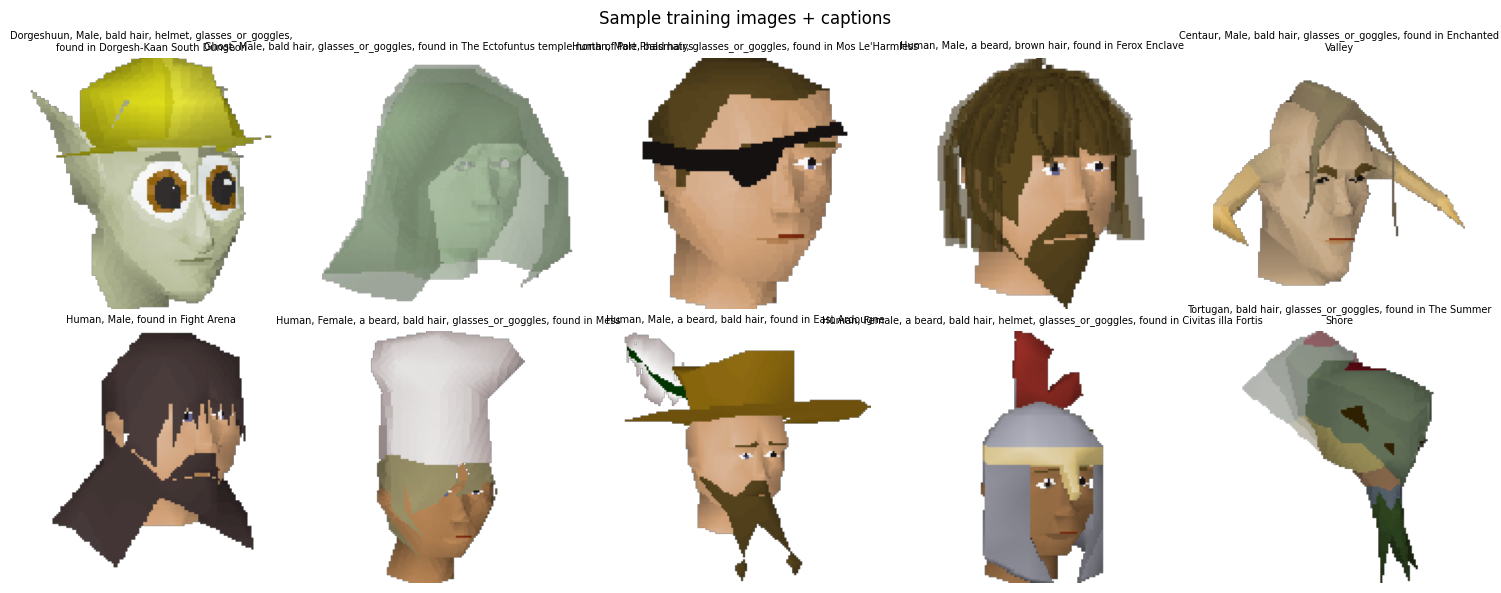

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample = manifest.sample(10, random_state=7).reset_index(drop=True)
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(f"{DATA_DIR}/{row['file_name']}")
    ax.imshow(img)
    ax.set_title(row["text"], fontsize=7, wrap=True)
    ax.axis("off")
plt.suptitle("Sample training images + captions")
plt.tight_layout()
plt.show()

## Train

Runs the vendored `train_text_to_image_lora.py` (HuggingFace `diffusers` example script,
unmodified) as a subprocess so its progress streams into this notebook's saved output. Single
GPU, so the script is invoked directly with `python` rather than through `accelerate launch`
(the launcher wrapper is for multi-process/multi-GPU setups; `Accelerator()` inside the script
already handles single-GPU init on its own).

- `--variant=fp16` + `--mixed_precision=fp16` -- halves the SD1.5 download/VRAM footprint,
  important since we're sharing an 8GB GPU with the desktop session
- `--resolution=128` -- matches the preprocessing pipeline's target size
- `--train_batch_size=4`, `--max_train_steps=2000` -- ~4.7 epochs over the 1,712-image set
- `--rank=8` -- same LoRA rank as the feasibility MVP

In [4]:
cmd = [
    sys.executable, "train_text_to_image_lora.py",
    "--pretrained_model_name_or_path=runwayml/stable-diffusion-v1-5",
    "--variant=fp16",
    "--train_data_dir=" + DATA_DIR,
    "--resolution=128",
    "--center_crop",
    "--random_flip",
    "--train_batch_size=4",
    "--max_train_steps=2000",
    "--learning_rate=1e-4",
    "--lr_scheduler=constant",
    "--lr_warmup_steps=0",
    "--rank=8",
    "--mixed_precision=fp16",
    "--seed=42",
    "--output_dir=" + OUTPUT_DIR,
    "--checkpointing_steps=1000",
]
print(" ".join(cmd))

process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in process.stdout:
    print(line, end="")
process.wait()
print(f"\nExit code: {process.returncode}")
assert process.returncode == 0, 'LoRA training failed -- see log above'

C:\Python313\python.exe train_text_to_image_lora.py --pretrained_model_name_or_path=runwayml/stable-diffusion-v1-5 --variant=fp16 --train_data_dir=../data/chatheads_processed --resolution=128 --center_crop --random_flip --train_batch_size=4 --max_train_steps=2000 --learning_rate=1e-4 --lr_scheduler=constant --lr_warmup_steps=0 --rank=8 --mixed_precision=fp16 --seed=42 --output_dir=../data/lora_champion_output --checkpointing_steps=1000


I0000 00:00:1785772950.291671   18864 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1785772951.780887   18864 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


W0803 11:02:35.494000 27004 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


08/03/2026 11:02:36 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16



...

Steps: 100%|#########9| 1997/2000 [06:44<00:00,  5.02it/s, lr=0.0001, step_loss=0.0471]


Steps: 100%|#########9| 1999/2000 [06:44<00:00,  4.99it/s, lr=0.0001, step_loss=0.0844]


Steps: 100%|##########| 2000/2000 [06:44<00:00,  4.99it/s, lr=0.0001, step_loss=0.373]08/03/2026 11:09:51 - INFO - accelerate.accelerator - [RANK 0] Saving current state to ../data/lora_champion_output\checkpoint-2000
Model weights saved in ../data/lora_champion_output/checkpoint-2000/pytorch_lora_weights.safetensors
08/03/2026 11:09:51 - INFO - accelerate.checkpointing - [RANK 0] Optimizer state saved in ..\data\lora_champion_output\checkpoint-2000\optimizer.bin
08/03/2026 11:09:51 - INFO - accelerate.checkpointing - [RANK 0] Scheduler state saved in ..\data\lora_champion_output\checkpoint-2000\scheduler.bin
08/03/2026 11:09:51 - INFO - accelerate.checkpointing - [RANK 0] Sampler state for dataloader 0 saved in ..\data\lora_champion_output\checkpoint-2000\sampler.bin
08/03/2026 11:09:51 - INFO - accelerate.checkpointing - [RANK 0] Gradient scaler state saved in ..\data\lora_champion_output\checkpoint-2000\scaler.pt
08/03/2026 11:09:51 - INFO - accelerate.checkpointing - [RANK 0] Rando

Model weights saved in ../data/lora_champion_output/pytorch_lora_weights.safetensors

Steps: 100%|##########| 2000/2000 [06:45<00:00,  4.93it/s, lr=0.0001, step_loss=0.0295]



Exit code: 0


## Generate a qualitative sample grid across classes

In [5]:
import torch
from diffusers import StableDiffusionPipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", variant="fp16", torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    safety_checker=None,
).to(DEVICE)
pipe.load_lora_weights(OUTPUT_DIR)
pipe.set_progress_bar_config(disable=True)
print("Champion LoRA pipeline loaded.")

W0803 11:10:03.694000 16780 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Champion LoRA pipeline loaded.


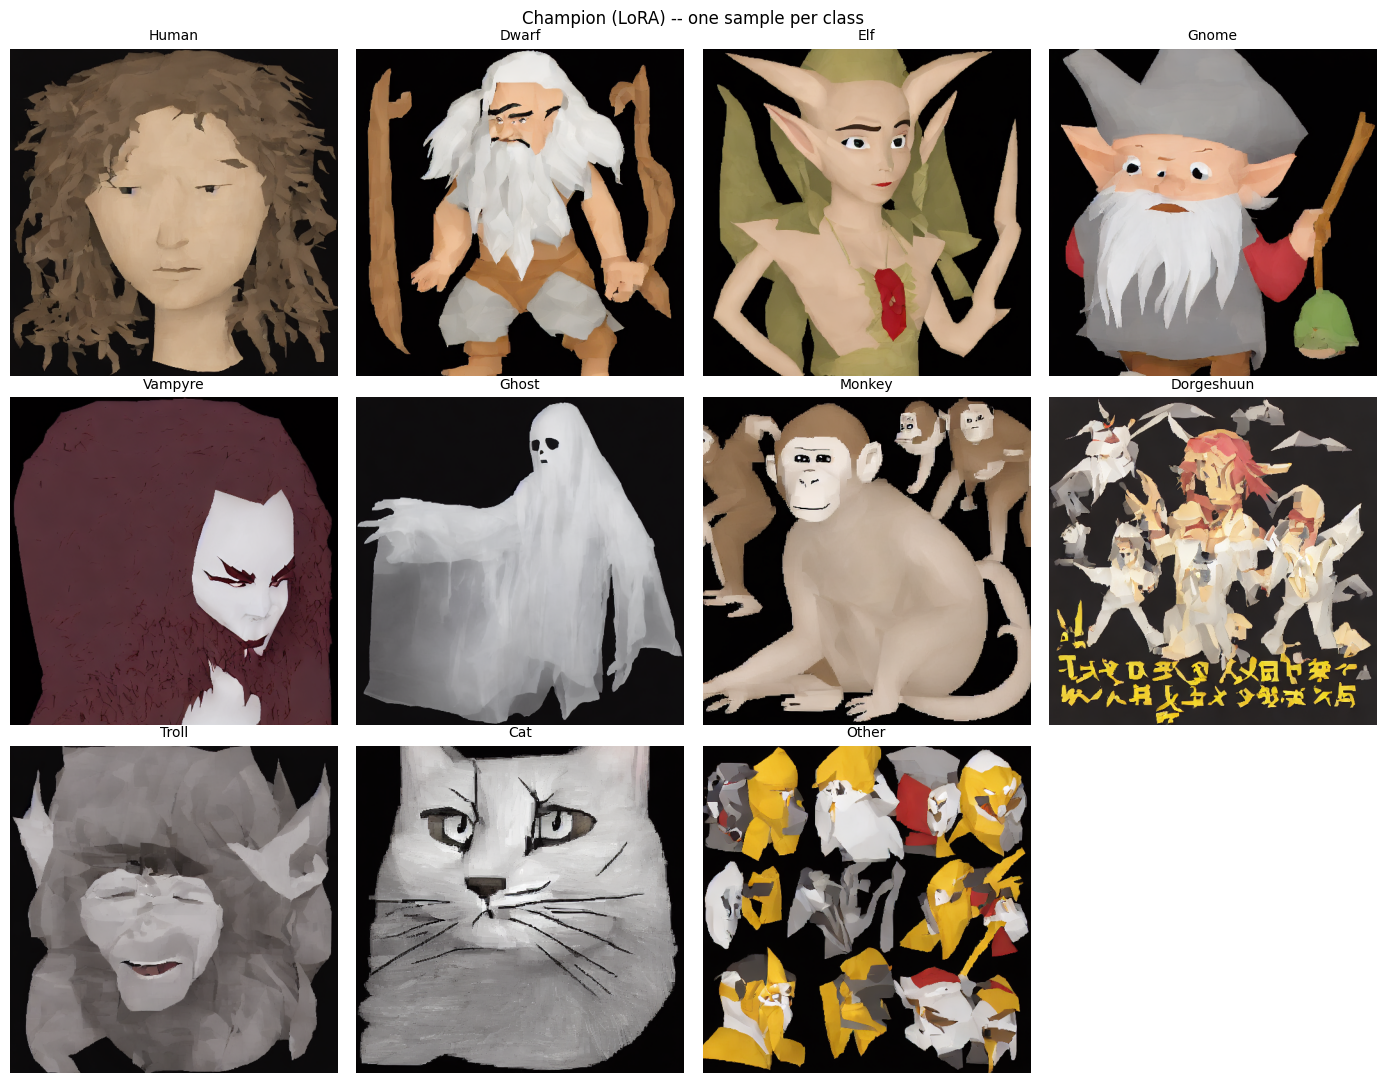

In [6]:
CLASS_NAMES = ["Human", "Dwarf", "Elf", "Gnome", "Vampyre", "Ghost", "Monkey", "Dorgeshuun", "Troll", "Cat", "Other"]

generator = torch.Generator(device=DEVICE).manual_seed(42)
samples = {}
for cls in CLASS_NAMES:
    prompt = cls if cls != "Other" else "an OSRS character"
    image = pipe(prompt, num_inference_steps=30, generator=generator).images[0]
    samples[cls] = image

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, cls in zip(axes.flat, CLASS_NAMES):
    ax.imshow(samples[cls])
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(CLASS_NAMES):]:
    ax.axis("off")
plt.suptitle("Champion (LoRA) -- one sample per class")
plt.tight_layout()
plt.savefig("../img/lora_champion_samples.png")
plt.show()

In [7]:
SAMPLES_DIR = "../data/lora_champion_samples"
os.makedirs(SAMPLES_DIR, exist_ok=True)
for cls, img in samples.items():
    img.save(f"{SAMPLES_DIR}/{cls}.png")
print(f"Saved {len(samples)} sample images to {SAMPLES_DIR}")

Saved 11 sample images to ../data/lora_champion_samples
